In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

class FailureDetectionSystem:
    def __init__(self):
        self.features = ['Air temperature [K]', 'Process temperature [K]', 
                        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                        'Temp_Diff', 'Power']
        self.target_names = ['정상', '고장/이상']
        # [개선 1] class_weight='balanced'를 사용하여 적은 고장 데이터를 더 중요하게 학습
        self.model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

    def preprocess(self, df):
        df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
        df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']
        if 'Machine failure' not in df.columns:
            df['Machine failure'] = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].max(axis=1)
        return df

    def train_system(self, file_path):
        df = pd.read_csv(file_path)
        df = self.preprocess(df)
        X = df[self.features]
        y = df['Machine failure']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        # SMOTE로 고장 데이터 증폭
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
        self.model.fit(X_train_res, y_train_res)
        print("### 모델 학습 완료 (정밀 감지 모드) ###")

    def detect_failure(self, input_data):
        input_df = pd.DataFrame([input_data])
        input_df['Temp_Diff'] = input_df['Process temperature [K]'] - input_df['Air temperature [K]']
        input_df['Power'] = input_df['Rotational speed [rpm]'] * input_df['Torque [Nm]']
        
        # [개선 2] 단순 예측 대신 '확률'을 가져옴
        probs = self.model.predict_proba(input_df[self.features])[0]
        failure_prob = probs[1]
        failure_percent = failure_prob * 100
        
        # [개선 3] 감지 임계값(Threshold)을 0.2(20%)로 낮춤 
        # -> 조금만 이상해도 고장으로 의심하게 함
        custom_threshold = 0.2
        
        # [개선 4] 물리적 최소 지표 설정 (공학적 상식)
        is_abnormal_low = (input_data['Rotational speed [rpm]'] < 150) or (input_data['Torque [Nm]'] < 10)
        
        print(f"\n" + "="*50)
        print(f"### [장비 정밀 진단 결과] ###")
        print(f"예상 고장 확률: {failure_percent:.2f}%")
        
        if failure_prob >= custom_threshold or is_abnormal_low:
            print(f"상태: [⚠️ 고장 위험/이상 징후 감지]")
            # AI 확률과 물리적 이상을 종합하여 위험도 표시
            final_risk = max(failure_prob * 100, 90.0 if is_abnormal_low else 0)
            print(f"종합 위험도: {final_risk:.2f}%")
            
            print(f"\n[원인 분석]")
            if input_data['Rotational speed [rpm]'] < 150:
                print(f"- 저속 회전 이상: 현재 {input_data['Rotational speed [rpm]']} RPM (권장 1000 이상)")
            if input_data['Torque [Nm]'] < 10:
                print(f"- 저토크/무부하 이상: 현재 {input_data['Torque [Nm]']} Nm (기계 슬립 의심)")
            if failure_prob >= custom_threshold and not is_abnormal_low:
                print("- AI 모델이 데이터 패턴 기반의 미세한 이상 징후를 포착했습니다.")
        else:
            print(f"상태: [✅ 정상 가동 중]")
            print(f"안정 점수: {(1-failure_prob)*100:.2f}%")
        
        print("="*50)



In [29]:
# 테스트 실행
if __name__ == "__main__":
    system = FailureDetectionSystem()
    system.train_system('./machine_failure.csv')

    # 테스트: 매우 낮은 RPM (40) 입력
    test_data = {
        'Air temperature [K]': 305.0,
        'Process temperature [K]': 310.0,
        'Rotational speed [rpm]': 1450,
        'Torque [Nm]': 28.0,
        'Tool wear [min]': 130
    }
    system.detect_failure(test_data)

### 모델 학습 완료 (정밀 감지 모드) ###

### [장비 정밀 진단 결과] ###
예상 고장 확률: 5.00%
상태: [✅ 정상 가동 중]
안정 점수: 95.00%


In [21]:
import pandas as pd

df = pd.read_csv('./machine_failure.csv')

system = FailureDetectionSystem()
df = system.preprocess(df)

X = df[system.features]
y = df['Machine failure']

print("전체 데이터 수:", len(df))
print("고장 데이터 수:", y.sum())
print("고장 비율 (%):", y.mean() * 100)

전체 데이터 수: 10000
고장 데이터 수: 339
고장 비율 (%): 3.39


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train 고장 수:", y_train.sum())
print("Test 고장 수:", y_test.sum())

Train 고장 수: 271
Test 고장 수: 68


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("SMOTE 전:", y_train.value_counts())
print("SMOTE 후:", y_train_res.value_counts())

SMOTE 전: Machine failure
0    7729
1     271
Name: count, dtype: int64
SMOTE 후: Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [25]:
X_train_res, y_train_res = X_train, y_train

print("SMOTE 전:", y_train.value_counts())
print("SMOTE 후:", y_train_res.value_counts())

SMOTE 전: Machine failure
0    7729
1     271
Name: count, dtype: int64
SMOTE 후: Machine failure
0    7729
1     271
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,            # ⭐ 과적합 방지
    min_samples_leaf=5,     # ⭐ 과적합 방지
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

,n_estimators,150
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import classification_report

print("### TRAIN 성능 ###")
print(classification_report(y_train, model.predict(X_train)))

print("### TEST 성능 ###")
print(classification_report(y_test, model.predict(X_test)))

### TRAIN 성능 ###
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7729
           1       0.78      0.97      0.87       271

    accuracy                           0.99      8000
   macro avg       0.89      0.98      0.93      8000
weighted avg       0.99      0.99      0.99      8000

### TEST 성능 ###
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.65      0.87      0.74        68

    accuracy                           0.98      2000
   macro avg       0.82      0.93      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(X_test))
print("Confusion Matrix [TN FP / FN TP]")
print(cm)

Confusion Matrix [TN FP / FN TP]
[[1900   32]
 [   9   59]]


In [29]:
from sklearn.metrics import roc_auc_score

y_test_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_test_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.979


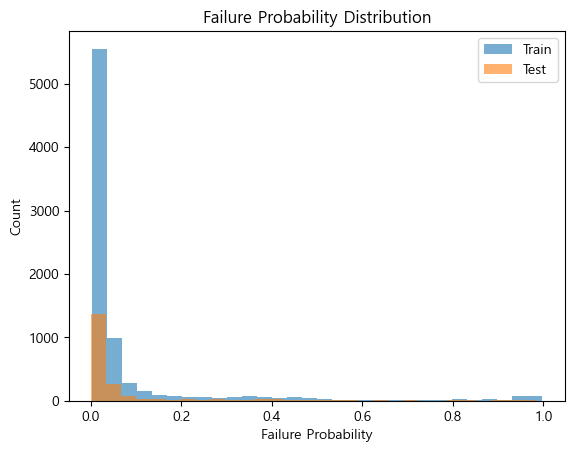

In [30]:
import matplotlib.pyplot as plt

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

plt.hist(train_probs, bins=30, alpha=0.6, label='Train')
plt.hist(test_probs, bins=30, alpha=0.6, label='Test')
plt.legend()
plt.title("Failure Probability Distribution")
plt.xlabel("Failure Probability")
plt.ylabel("Count")
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recall_scores = cross_val_score(
    model, X, y,
    cv=cv,
    scoring='recall'
)

print("Fold별 Recall:", recall_scores)
print("Recall 평균:", recall_scores.mean())
print("Recall 표준편차:", recall_scores.std())

Fold별 Recall: [0.82089552 0.82352941 0.79411765 0.89705882 0.75      ]
Recall 평균: 0.8171202809482001
Recall 표준편차: 0.047916079297401874


In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 시각화를 위한 평가 함수 추가
def visualize_model_performance(system, file_path):
    # 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = system.preprocess(df)
    X = df[system.features]
    y = df['Machine failure']
    
    # 학습/테스트 분할 (학습 때와 동일한 환경)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 예측 (임계값 0.2 적용)
    y_probs = system.model.predict_proba(X_test)[:, 1]
    y_pred_custom = (y_probs >= 0.2).astype(int)
    
    # 한글 폰트 설정 (PPT용 - 폰트가 깨지면 'Malgun Gothic' 등으로 변경)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 그래프 레이아웃 설정
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # --- [그래프 1] Confusion Matrix 히트맵 ---
    cm = confusion_matrix(y_test, y_pred_custom)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['정상 예측', '고장 예측'],
                yticklabels=['실제 정상', '실제 고장'])
    ax[0].set_title('Confusion Matrix (Threshold: 0.2)', fontsize=15)
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # --- [그래프 2] Feature Importance ---
    importances = system.model.feature_importances_
    indices = np.argsort(importances)
    
    ax[1].barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    ax[1].set_yticks(range(len(indices)))
    ax[1].set_yticklabels([system.features[i] for i in indices])
    ax[1].set_title('주요 변수 중요도 (Feature Importance)', fontsize=15)
    ax[1].set_xlabel('Relative Importance')

    plt.tight_layout()
    plt.show()
    
    # 상세 지표 출력
    print("\n[상세 성능 분석 리포트]")
    print(classification_report(y_test, y_pred_custom, target_names=['정상', '고장']))

In [ ]:
detector = FailureDetectionSystem()
detector.train_system('data/raw/machine_failure.csv')
visualize_model_performance(detector, 'data/raw/machine_failure.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'machine_failure.csv'